# Data Cleaning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('blackFriday_train.csv')

In [3]:
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  str    
 2   Gender                      550068 non-null  str    
 3   Age                         550068 non-null  str    
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  str    
 6   Stay_In_Current_City_Years  550068 non-null  str    
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), str(5)
memory usage: 50.4 MB
None


In [4]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [5]:
df.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

In [6]:
df['Product_Category_2'] = df['Product_Category_2'].fillna(0).astype(int)
df['Product_Category_3'] = df['Product_Category_3'].fillna(0).astype(int)

In [7]:
df


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,0,0,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6,14,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,0,0,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14,0,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,0,0,7969
...,...,...,...,...,...,...,...,...,...,...,...,...
550063,1006033,P00372445,M,51-55,13,B,1,1,20,0,0,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,0,0,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,0,0,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,0,0,365


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   User_ID                     550068 non-null  int64
 1   Product_ID                  550068 non-null  str  
 2   Gender                      550068 non-null  str  
 3   Age                         550068 non-null  str  
 4   Occupation                  550068 non-null  int64
 5   City_Category               550068 non-null  str  
 6   Stay_In_Current_City_Years  550068 non-null  str  
 7   Marital_Status              550068 non-null  int64
 8   Product_Category_1          550068 non-null  int64
 9   Product_Category_2          550068 non-null  int64
 10  Product_Category_3          550068 non-null  int64
 11  Purchase                    550068 non-null  int64
dtypes: int64(7), str(5)
memory usage: 50.4 MB


In [9]:
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].str.replace('+', '').astype(int)

In [10]:
df['product_mean'] = df.groupby('Product_ID')['Purchase'].transform('mean')
df['user_mean'] = df.groupby('User_ID')['Purchase'].transform('mean')
df['user_count'] = df.groupby('User_ID')['Purchase'].transform('count')
df['product_count'] = df.groupby('Product_ID')['Purchase'].transform('count')


In [11]:
df.drop(['User_ID', 'Product_ID'], axis=1, inplace=True)

In [12]:
print(f"Total Rows: {len(df)}")

Total Rows: 550068


In [13]:
print(f"Total Duplicates: {df.duplicated().sum()}")

Total Duplicates: 0


In [14]:
df.drop_duplicates(inplace=True)


In [15]:
print(f"Total Rows: {len(df)}")

Total Rows: 550068


# EDA

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Target variable distribution

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Purchase'], kde=True)
plt.title("Purchase Distribution")
plt.show()

# Gender vs Purchase

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x='Gender', y='Purchase', data=df)
plt.title("Gender vs Purchase")
plt.show()

# Age vs Purchase

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='Age', y='Purchase', data=df)
plt.title("Age vs Purchase")
plt.xticks(rotation=45)
plt.show()

# City Category vs Purchase

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x='City_Category', y='Purchase', data=df)
plt.title("City Category vs Purchase")
plt.show()

# Marital Status vs Purchase

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x='Marital_Status', y='Purchase', data=df)
plt.title("Marital Status vs Purchase")
plt.show()

# Stay in city vs Purchase

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x='Stay_In_Current_City_Years', y='Purchase', data=df)
plt.title("Stay Years vs Purchase")
plt.show()

# Product Category analysis

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='Product_Category_1', y='Purchase', data=df)
plt.title("Product Category 1 vs Purchase")
plt.show()

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='Product_Category_2', y='Purchase', data=df)
plt.title("Product Category 2 vs Purchase")
plt.show()

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='Product_Category_3', y='Purchase', data=df)
plt.title("Product Category 3 vs Purchase")
plt.show()

# Occupation vs Purchase

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='Occupation', y='Purchase', data=df)
plt.title("Occupation vs Purchase")
plt.show()

# Correlation heatmap

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# Purchase boxplot (outliers)

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['Purchase'])
plt.title("Purchase Boxplot")
plt.show()

# Handle outliers

In [15]:
Q1 = df['Purchase'].quantile(0.25)
Q3 = df['Purchase'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower limit:", lower)
print("Upper limit:", upper)

Lower limit: -3523.5
Upper limit: 21400.5


In [16]:
df['Purchase'] = np.where(df['Purchase'] > upper, upper, df['Purchase'])
df['Purchase'] = np.where(df['Purchase'] < lower, lower, df['Purchase'])

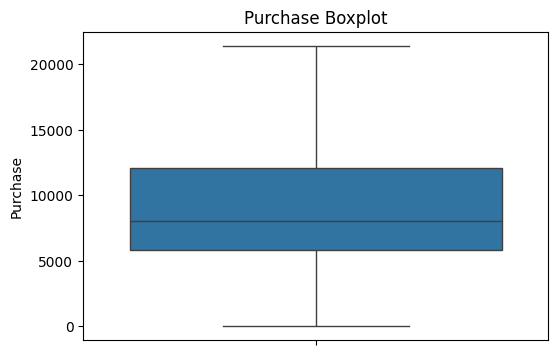

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['Purchase'])
plt.title("Purchase Boxplot")
plt.show()

# Label Encoding

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Age'] = le.fit_transform(df['Age'])
df['Stay_In_Current_City_Years'] = le.fit_transform(df['Stay_In_Current_City_Years'])

In [19]:
df = pd.get_dummies(df, columns=['City_Category'], drop_first=True, dtype=int)

In [20]:
df.head()

,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,product_mean,user_mean,user_count,product_count,City_Category_B,City_Category_C
0,F,0,10,2,0,3,0,0,8370.0,11870.863436,9545.514286,35,227,0,0
1,F,0,10,2,0,1,6,14,15200.0,16304.030981,9545.514286,35,581,0,0
2,F,0,10,2,0,12,0,0,1422.0,1237.892157,9545.514286,35,102,0,0
3,F,0,10,2,0,12,14,0,1057.0,1455.140762,9545.514286,35,341,0,0
4,M,6,16,4,0,8,0,0,7969.0,7692.763547,10525.610390,77,203,0,1


In [21]:
df['Gender']=df['Gender'].map({
    "F" : 0,
    "M" : 1
})

In [22]:
df['Gender']= df['Gender'].astype(int)


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 15 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Gender                      550068 non-null  int64  
 1   Age                         550068 non-null  int64  
 2   Occupation                  550068 non-null  int64  
 3   Stay_In_Current_City_Years  550068 non-null  int64  
 4   Marital_Status              550068 non-null  int64  
 5   Product_Category_1          550068 non-null  int64  
 6   Product_Category_2          550068 non-null  int64  
 7   Product_Category_3          550068 non-null  int64  
 8   Purchase                    550068 non-null  float64
 9   product_mean                550068 non-null  float64
 10  user_mean                   550068 non-null  float64
 11  user_count                  550068 non-null  int64  
 12  product_count               550068 non-null  int64  
 13  City_Category_B          

# scaling

In [24]:
X = df.drop('Purchase', axis=1)
y = df['Purchase']

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train_sc = sc.fit_transform(X_train)
X_val_sc = sc.transform(X_val)

# Model Building

# Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_sc, y_train)

In [ ]:
y_pred = lr.predict(X_val_sc)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

# KNN Regressor

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=7)
knn.fit(X_train_sc, y_train)

In [ ]:
y_pred_knn = knn.predict(X_val_sc)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_val, y_pred_knn))
mae = mean_absolute_error(y_val, y_pred_knn)
r2 = r2_score(y_val, y_pred_knn)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

In [ ]:
rmse_values = []

for k in range(1, 11):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train_sc, y_train)
    pred = model.predict(X_val_sc)
    rmse_values.append(np.sqrt(mean_squared_error(y_val, pred)))

plt.plot(range(1,11), rmse_values, marker='o')
plt.xlabel("K value")
plt.ylabel("RMSE")
plt.title("K vs RMSE")
plt.show()

# Train Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

In [ ]:
y_pred_dt = dt.predict(X_val)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_val, y_pred_dt))
mae = mean_absolute_error(y_val, y_pred_dt)
r2 = r2_score(y_val, y_pred_dt)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

# Tuned Decision Tree

In [ ]:
dt = DecisionTreeRegressor(
    max_depth=9,
    random_state=42,

)

dt.fit(X_train, y_train)

In [ ]:
y_pred_dt = dt.predict(X_val)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_val, y_pred_dt))
mae = mean_absolute_error(y_val, y_pred_dt)
r2 = r2_score(y_val, y_pred_dt)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42)
rf_model.fit(X_train_sc, y_train)


In [ ]:
y_pred_dt = rf_model.predict(X_val_sc)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_dt))
mae = mean_absolute_error(y_val, y_pred_dt)
r2 = r2_score(y_val, y_pred_dt)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

In [ ]:
importances = rf_model.feature_importances_
feature_list = X.columns

importance_df = (
    pd.DataFrame({'Feature': feature_list, 'Importance': importances})
      .sort_values(by='Importance', ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance: What drives Purchase Amount?')
plt.show()


#### Bagging Regressor

In [ ]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

base_model =  DecisionTreeRegressor(max_depth=16)

bagging_model = BaggingRegressor(estimator=base_model, 
                                 n_estimators=100, 
                                 random_state=42)

bagging_model.fit(X_train_sc, y_train)



In [ ]:
y_pred_dt = bagging_model.predict(X_val_sc)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_dt))
mae = mean_absolute_error(y_val, y_pred_dt)
r2 = r2_score(y_val, y_pred_dt)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

# AdaBoostRegressor

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
base_tree = DecisionTreeRegressor(max_depth=10)
ada_model = AdaBoostRegressor(estimator=base_tree, 
                              n_estimators=100, 
                              learning_rate=0.1, 
                              random_state=42)

ada_model.fit(X_train_sc, y_train)


In [ ]:
y_pred_dt = ada_model.predict(X_val_sc)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_dt))
mae = mean_absolute_error(y_val, y_pred_dt)
r2 = r2_score(y_val, y_pred_dt)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

# Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbm_model = GradientBoostingRegressor(n_estimators=100, 
                                      learning_rate=0.1, 
                                      max_depth=5, 
                                      random_state=42)
gbm_model.fit(X_train_sc, y_train)



In [ ]:
y_pred_dt = gbm_model.predict(X_val_sc)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_dt))
mae = mean_absolute_error(y_val, y_pred_dt)
r2 = r2_score(y_val, y_pred_dt)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

# ML pipeline

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
import joblib

In [28]:
base_model =  DecisionTreeRegressor(max_depth=16)
model = Pipeline([
    ("scaler",StandardScaler()),
    ("model",BaggingRegressor(estimator=base_model, 
                                 n_estimators=100, 
                                 random_state=42))
    
])

In [29]:
model.fit(X_train_sc,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeRegressor`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeR...(max_depth=16)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0


In [ ]:
y_pred_dt = model.predict(X_val_sc)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_dt))
mae = mean_absolute_error(y_val, y_pred_dt)
r2 = r2_score(y_val, y_pred_dt)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

In [ ]:
joblib.dump(model,"Black_Friday_Model.h5")